# Семинар 5: детекция объектов

Область детектирования изображений с использованием глубокого обучения постоянно развивается – появляется множество новых техник и моделей, которые находят применение в промышленном производстве. Одной из таких возможных областей применения является детектирование дефектов в фоторезистивной маске на изображениях тестовых структур, полученных со сканирующего электронного микроскопа (SEM, scanning electron microscope). Использование традиционных методов обнаружения дефектов требует значительных затрат времени и средств, так как эти методы основаны на ручном анализе изображений и требуют высокой квалификации специалистов. Данные методы имеют определённые ограничения, поскольку выполняемая классификация дефектов основана на заранее заложенных правилах. Эти ограничения часто приводят к неправильной классификации дефектов, тем самым увеличивая время анализа снимков. Кроме того, эти методы не позволяют обнаруживать и классифицировать новые типы дефектов, возникающих при переходе к более низким технологическим нормам. Возможное наличие шума на SEM-изображениях также негативно влияет на корректность результата детектирования. Использование нейросетевых детекторов позволяет автоматизировать процесс детекции дефектов при анализе больших наборов изображений, обеспечивает устойчивость к шуму и возможность обнаружения новых дефектных структур.


На этом занятии мы обучим модель `YOLO` для решения задачи поиска и классификации дефектов фоторезистиной маски на SEM-изображениях.

Детекции объектов вернеуровнево сводится к тому, чтобы объединить две отдельные задачи - классификация объектов и регрессия координат ограничивающих рамок.



## Загрузка данных. Импорт библиотек.

In [ ]:
!pip install roboflow

In [ ]:
!pip install roboflow

Существует удобный фреймворк [Roboflow](https://roboflow.com/), благодаря которому можно легко находить, размечать и создавать данные для разных задач, в том числе сегментации и детекции.

### Какие проблемы решает Roboflow?

**Roboflow** реализован как обычный питновский пакет, что упрощает его использование.

**В детекции** существуют ряд сложностей с данными и моделями, поэтому для всех них требуется специальный формат и поля (для разных данных и моделей)

* Регистрируемся на сайте https://roboflow.com/ (через тот же гугл аккаунт, что и коллаб, самое простое)

**Roboflow решает много проблем, например:**

1. Загрузка изображений и конвертация из одного формата в другой: https://roboflow.com/formats
2. Поиск и разметках данных. После регистрации можно поискать или разметить себе данные для любых задач, а также попробовать уже обученные модели на данные: https://universe.roboflow.com/
3. Удобный просмотр данных, их резделение, аугментации и трансформации; визуализации общей статистики.
4. Как в первом пункте, но уже после создания данных, можно под нужную задачу экспортировать данные.

In [ ]:
from roboflow import Roboflow
import cv2
import numpy as np
import matplotlib.pyplot as plt


rf = Roboflow(api_key="YrBQIkPs3zPlUZ2J6fSi")
project = rf.workspace("molecular-electronics-research-institute").project("defect-detection-ikxln")
version = project.version(11)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
dataset.__dict__

{'name': 'Defect Detection',
 'version': '11',
 'model_format': 'yolo26',
 'location': '/content/Defect-Detection-11'}

In [ ]:
ROOT_DIR = '/content/Defect-Detection-11'
train_imgs_dir = 'train/images'
train_labels_dir = 'train/labels'
val_imgs_dir = 'valid/images'
val_labels_dir = 'valid/labels'
test_imgs_dir = 'test/images'
test_labels_dir = 'test/labels'
classes = ['bridge', 'gap', 'sraf']

Для удобства создадим словарь по нашим данным с помощью которого мы сможем задать:
- корневую директорию с нашими данными;
- относительные пути до тренировочной, валидационной и тестовой выборок;
- категории классов


In [ ]:
dataset_params = {
    'data_dir':ROOT_DIR,
    'train_images_dir':train_imgs_dir,
    'train_labels_dir':train_labels_dir,
    'val_images_dir':val_imgs_dir,
    'val_labels_dir':val_labels_dir,
    'test_images_dir':test_imgs_dir,
    'test_labels_dir':test_labels_dir,
    'classes':classes
}

In [ ]:
colors = np.random.uniform(0, 255, size=(len(classes), 3))

Визуализируем наши размеченные данные:

In [ ]:
# Функция для конвертации bounding box-ов из формата YOLO в формат xmin, ymin, xmax, ymax
def yolo2bbox(bboxes):
    xmin, ymin = bboxes[0]-bboxes[2]/2, bboxes[1]-bboxes[3]/2
    xmax, ymax = bboxes[0]+bboxes[2]/2, bboxes[1]+bboxes[3]/2
    return xmin, ymin, xmax, ymax

In [ ]:
def plot_box(image, bboxes, labels):

    height, width, _ = image.shape
    lw = max(round(sum(image.shape) / 2 * 0.003), 2)  # ширина линии
    tf = max(lw - 1, 1) # толщина шрифта.
    for box_num, box in enumerate(bboxes):
        x1, y1, x2, y2 = yolo2bbox(box)
        # денормализация координат
        xmin = int(x1*width)
        ymin = int(y1*height)
        xmax = int(x2*width)
        ymax = int(y2*height)

        p1, p2 = (int(xmin), int(ymin)), (int(xmax), int(ymax))

        class_name = classes[int(labels[box_num])]

        color=colors[classes.index(class_name)]

        cv2.rectangle(
            image,
            p1, p2,
            color=(26,26,139),
            thickness=lw,
            lineType=cv2.LINE_AA
        )

        w, h = cv2.getTextSize(
            class_name,
            0,
            fontScale=lw / 3,
            thickness=tf
        )[0]

        outside = p1[1] - h >= 3
        p2 = p1[0] + w, p1[1] - h - 3 if outside else p1[1] + h + 3

        cv2.rectangle(
            image,
            p1, p2,
            color=(26,26,139),
            thickness=-1,
            lineType=cv2.LINE_AA
        )
        cv2.putText(
            image,
            class_name,
            (p1[0], p1[1] - 5 if outside else p1[1] + h + 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=lw/3.5,
            color=(255, 255, 255),
            thickness=tf,
            lineType=cv2.LINE_AA
        )
    return image

In [ ]:
# функция для отрисовки ограничивающих рамок на изображении
import os
import glob
import random

def plot(image_path, label_path, num_samples):
    all_training_images = glob.glob(image_path+'/*')
    all_training_labels = glob.glob(label_path+'/*')
    all_training_images.sort()
    all_training_labels.sort()

    temp = list(zip(all_training_images, all_training_labels))
    random.shuffle(temp)
    all_training_images, all_training_labels = zip(*temp)
    all_training_images, all_training_labels = list(all_training_images), list(all_training_labels)

    num_images = len(all_training_images)

    if num_samples == -1:
        num_samples = num_images

    plt.figure(figsize=(15, 12))
    for i in range(num_samples):
        image_name = all_training_images[i].split(os.path.sep)[-1]
        image = cv2.imread(all_training_images[i])
        with open(all_training_labels[i], 'r') as f:
            bboxes = []
            labels = []
            label_lines = f.readlines()
            for label_line in label_lines:
                label, x_c, y_c, w, h = label_line.split(' ')
                x_c = float(x_c)
                y_c = float(y_c)
                w = float(w)
                h = float(h)
                bboxes.append([x_c, y_c, w, h])
                labels.append(label)
        result_image = plot_box(image, bboxes, labels)
        plt.subplot(2, 2, i+1) # Visualize 2x2 grid of images.
        plt.imshow(image[:, :, ::-1])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Для создания датасета использовались изображения дефектов фоторезистивной маски в затворном слое для проектной нормы **28нм**. Датасет содержит **500 RGB** изображений формата “.tiff” размером **1024x1024 px**. При анализе имеющихся снимков удалось выделить 3 типа дефектных структур: **SRAF** (от англ. sub-resolution assist features) – вспомогательные непечатаемые структуры, добавляемые на кремниевую пластину для расширения окна процесса , **BRIDGE** – слияние двух соседних структур , **GAP** – промежуток в пределах одной структуры.

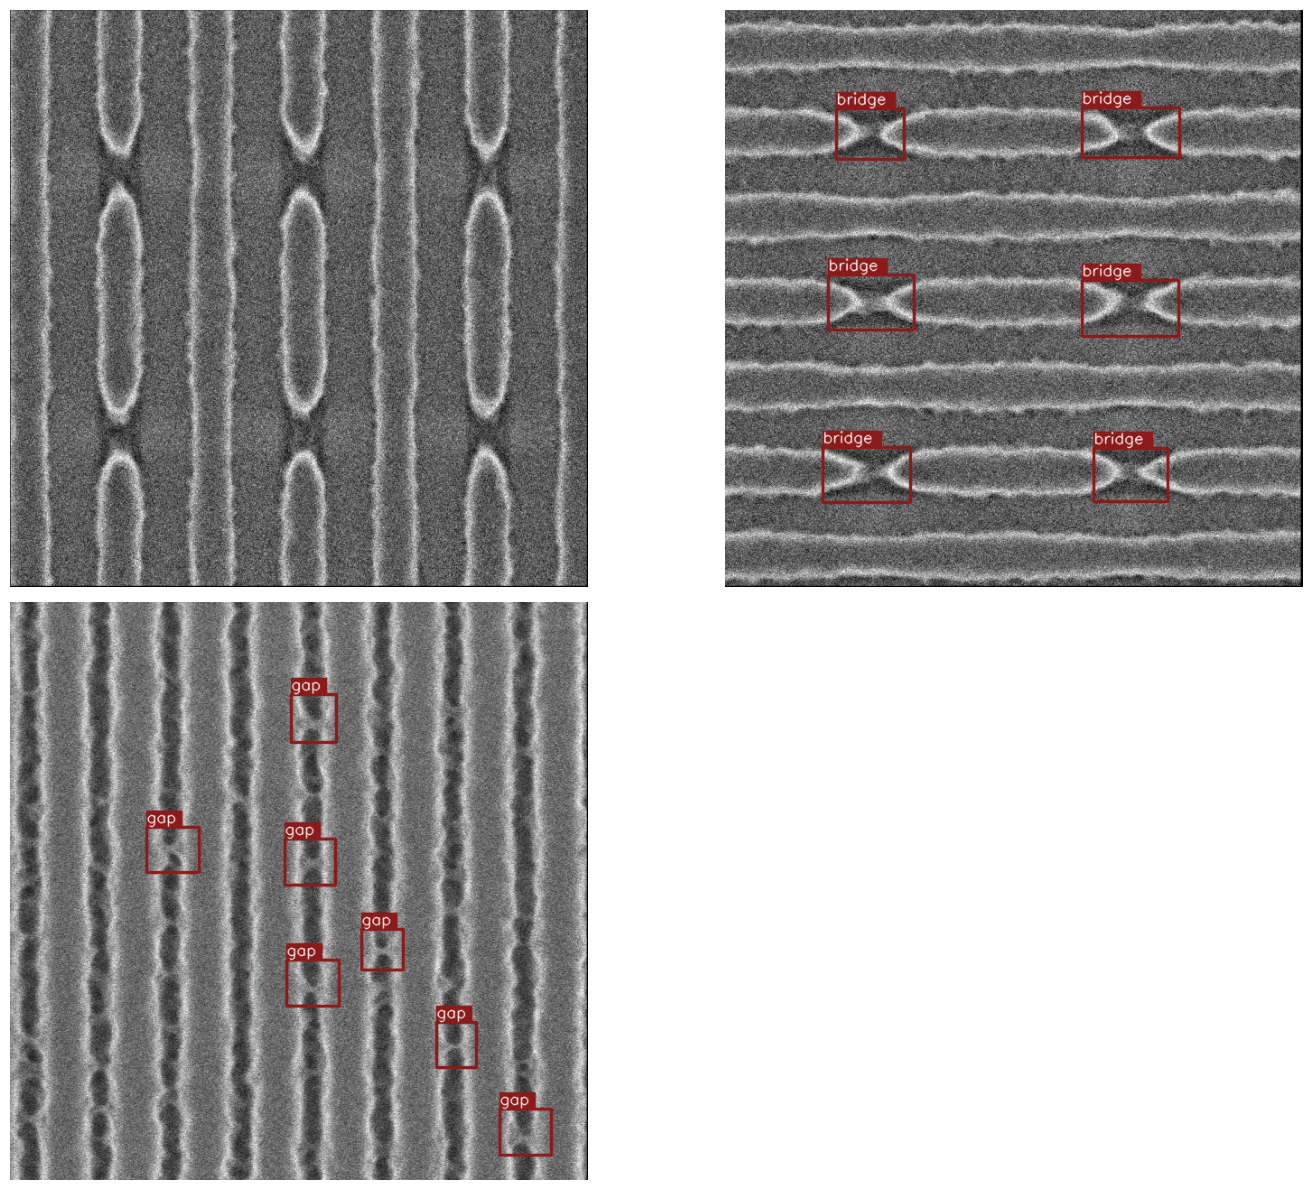

In [ ]:
# Визуализируем несколько примеров из нашей выборки
plot(
    image_path=os.path.join(ROOT_DIR, test_imgs_dir),
    label_path=os.path.join(ROOT_DIR, test_labels_dir),
    num_samples=3,
)

In [ ]:
!uv pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.9/112.6 GB disk)


## Обучение

In [ ]:
import os
from ultralytics import YOLO

# Загрузка модели
# model = YOLO('yolo26s.yaml')  # обучение модели с нуля
model = YOLO('yolo26s.pt')  # берём предобученную модель (рекомендуемый вариант)

data_path = os.path.join(dataset_params['data_dir'], 'data.yaml')
# запустим обучение модели
results = model.train(data=data_path,
                      epochs=25)

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Defect-Detection-11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

## Валидация

Оценим качество модели на валидационной выборке

In [ ]:
results = model.val()

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO26s summary (fused): 122 layers, 9,466,341 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1481.6±1030.3 MB/s, size: 123.5 KB)
val: Scanning /content/Defect-Detection-11/valid/labels.cache... 83 images, 15 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 83/83 24.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.4it/s 2.5s
                   all         83        290      0.806      0.806      0.855      0.515
                bridge         23         79      0.788      0.747      0.874      0.508
                   gap         13         85      0.715      0.741      0.737      0.367
                  sraf         32        126      0.914       0.93      0.953       0.67
Speed: 5.7ms preprocess, 11.3ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val3


## Инференс

Оценим предсказания модели на тестовой выборке

In [ ]:
# быстрый фикс проблемы с отображением предсказаний

!pip uninstall opencv-python-headless -y

Found existing installation: opencv-python-headless 4.10.0.84
Uninstalling opencv-python-headless-4.10.0.84:
  Successfully uninstalled opencv-python-headless-4.10.0.84


In [ ]:
!pip install opencv-python --upgrade

Напомним, что собой представляет формат предсказания модели. На выходе для каждого объекта на картинке мы будет получать **координаты ограничивающей рамки** (x_min, y_min, x_max, y_max), **вероятность обнаружить объект внутри рамки**, **распределение вероятностей по классам** (в нашем случае 3 вероятности, так как 3 класса) или вероятность классса с "наибольшим значением вероятности".
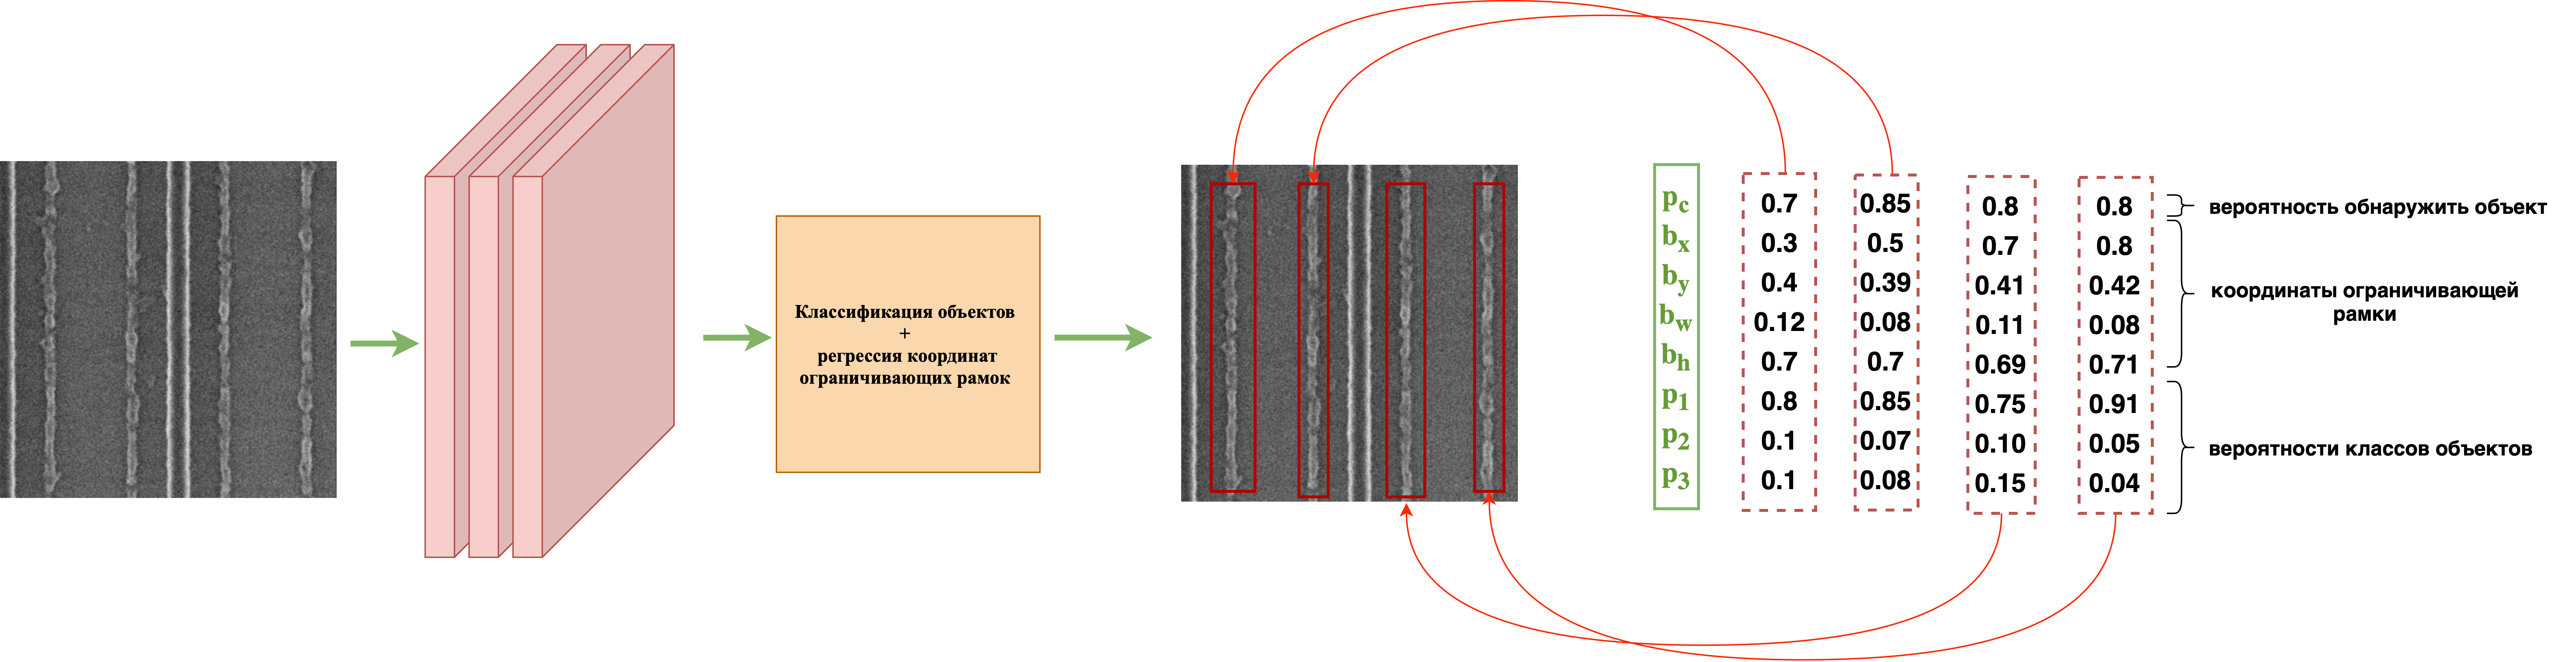



Получим предсказание обученной модели на одном изображении:

In [ ]:
import ultralytics
from ultralytics import YOLO
img_source = "/content/Defect-Detection-11/test/images/E04_M0176-01MS_jpg.rf.d9b9974f1012895780290816331d1322.jpg"

model = YOLO('/content/runs/detect/train2/weights/best.pt')
model.predict(img_source, save=True)


image 1/1 /content/Defect-Detection-11/test/images/E04_M0176-01MS_jpg.rf.d9b9974f1012895780290816331d1322.jpg: 640x640 3 srafs, 16.8ms
Speed: 1.8ms preprocess, 16.8ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict6


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'bridge', 1: 'gap', 2: 'sraf'}
 obb: None
 orig_img: array([[[ 93,  93,  93],
         [ 85,  85,  85],
         [ 57,  57,  57],
         ...,
         [ 82,  82,  82],
         [ 93,  93,  93],
         [ 72,  72,  72]],
 
        [[ 96,  96,  96],
         [ 67,  67,  67],
         [ 58,  58,  58],
         ...,
         [132, 132, 132],
         [ 88,  88,  88],
         [ 92,  92,  92]],
 
        [[ 90,  90,  90],
         [ 86,  86,  86],
         [ 75,  75,  75],
         ...,
         [ 84,  84,  84],
         [ 38,  38,  38],
         [ 91,  91,  91]],
 
        ...,
 
        [[ 84,  84,  84],
         [ 99,  99,  99],
         [113, 113, 113],
         ...,
         [ 87,  87,  87],
         [120, 120, 120],
         [101, 101, 101]],
 
        [[148, 148, 148],
         [ 95,  95,  95],
         [109, 109, 109],
         ..

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/predict4/E04_M0176-01MS_jpg.rf.d9b9974f1012895780290816331d1322.jpg"))

Получим предсказание модели на тестовой выборке изображений. Передаём путь до изображений из тестовой выборки.

In [ ]:
import os
results = model(os.path.join(dataset_params["data_dir"], dataset_params["test_images_dir"]), save=True)  # predict for the directory


image 1/37 /content/Defect-Detection-11/test/images/E04_M0176-01MS_jpg.rf.d9b9974f1012895780290816331d1322.jpg: 640x640 3 srafs, 16.9ms
image 2/37 /content/Defect-Detection-11/test/images/E04_M0262-01MS_jpg.rf.a74bb37a6343e00b42415927e2c4058d.jpg: 640x640 7 srafs, 16.8ms
image 3/37 /content/Defect-Detection-11/test/images/E04_M0316-01MS_jpg.rf.91603639c26af09381419267ed6b6cf2.jpg: 640x640 4 srafs, 16.8ms
image 4/37 /content/Defect-Detection-11/test/images/E04_M0412-01MS_jpg.rf.863126bde13b0d91ef251cc7876266aa.jpg: 640x640 5 srafs, 16.8ms
image 5/37 /content/Defect-Detection-11/test/images/E04_M0603-01MS_jpg.rf.2f175fd269e082ffe862a3c8d0a5f47e.jpg: 640x640 5 srafs, 16.8ms
image 6/37 /content/Defect-Detection-11/test/images/E04_M0699-01MS_jpg.rf.f4acccd62867ff851afb74cdd80022df.jpg: 640x640 6 srafs, 16.8ms
image 7/37 /content/Defect-Detection-11/test/images/E04_M0784-01MS_jpg.rf.30f97f4be073c919261f2691c13752cc.jpg: 640x640 4 srafs, 16.8ms
image 8/37 /content/Defect-Detection-11/test/im

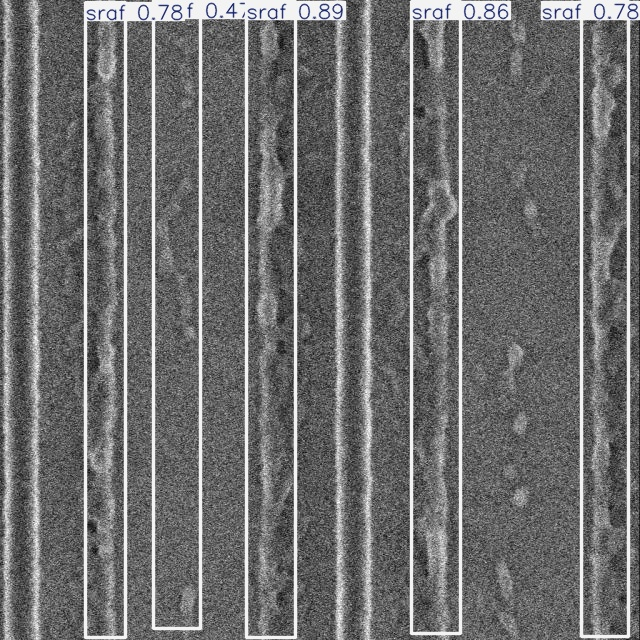

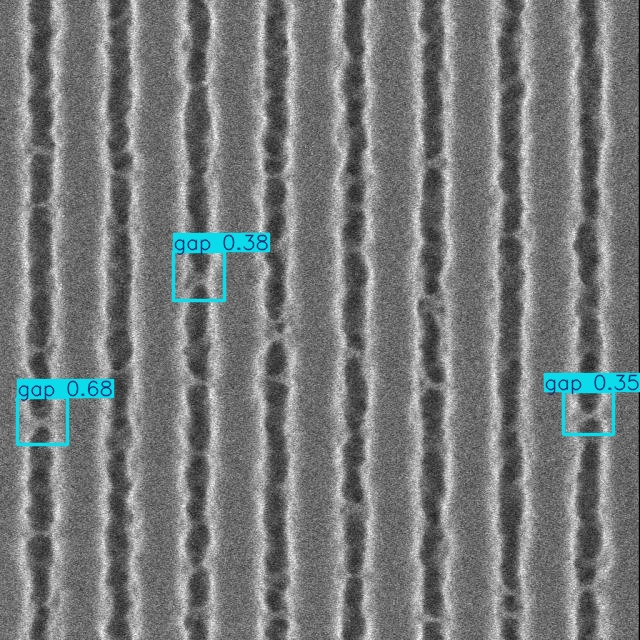

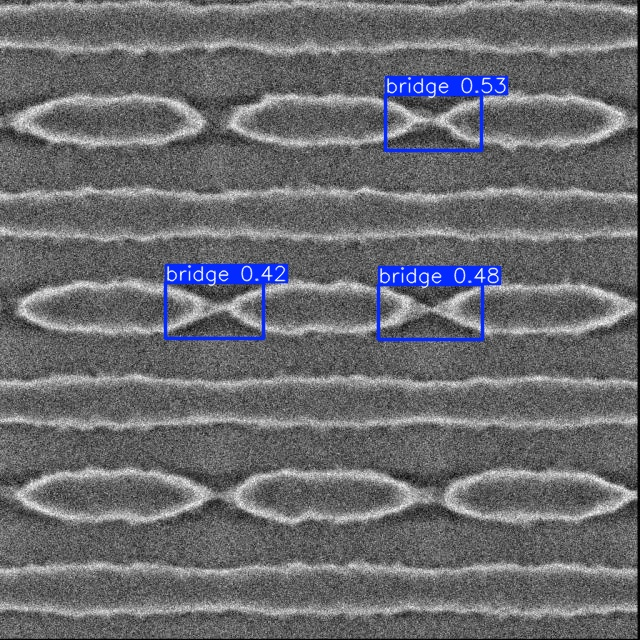

In [ ]:
# display inference on ALL test images
from IPython.display import Image, display
import glob

i = 0
limit = 3  # max images to print
for imageName in glob.glob("/content/runs/detect/predict6/*.jpg"):  # assuming JPG
    if i < limit:
        display(Image(filename=imageName))
        print("\n")
    i = i + 1